In [17]:
import nonlinear_dce
import nonlinear
import torch
import numpy as np
import networkx as nx
import pandas as pd
import torch.nn as nn
from locally_connected import LocallyConnected
import json
import argparse
import random
from torch.func import jacrev, vmap
import time
import bnlearn as bn
import pooch
from causallearn.utils.Dataset import load_dataset

In [27]:
# data from causal-learn
data, labels = load_dataset("sachs")

# make column names match bnlearn convention
rename = {
    "pka": "PKA",
    "pkc": "PKC",
    "p38": "P38",
    "pip2": "PIP2",
    "pip3": "PIP3",
    "plc": "Plcg",
    "raf": "Raf",
    "mek": "Mek",
    "erk": "Erk",
    "akt": "Akt",
    "jnk": "Jnk",
}

labels = [rename.get(str(x).lower(), str(x)) for x in labels]
df = pd.DataFrame(data, columns=labels)

# ground-truth DAG from bnlearn
ground_truth_dag = bn.import_DAG("sachs", verbose=False)
G = ground_truth_dag["model"]

# reorder data columns according to bnlearn graph nodes
graph_nodes = list(G.nodes())
df = df[graph_nodes]

print(df.columns.tolist())
print(graph_nodes)

['Erk', 'Akt', 'PKA', 'Mek', 'Jnk', 'PKC', 'Raf', 'P38', 'PIP3', 'PIP2', 'Plcg']
['Erk', 'Akt', 'PKA', 'Mek', 'Jnk', 'PKC', 'Raf', 'P38', 'PIP3', 'PIP2', 'Plcg']


In [43]:
hidden_var = "PKC"

df_obs = df.drop(columns=[hidden_var])
# df_obs = df_obs.sample(n=2000, random_state=0).reset_index(drop=True)

X_truth = torch.tensor(df_obs.values, dtype=torch.float64)

var_names = list(df_obs.columns)
name_to_idx = {name: i for i, name in enumerate(var_names)}

print(X_truth.shape)
print(var_names)

torch.Size([7466, 10])
['Erk', 'Akt', 'PKA', 'Mek', 'Jnk', 'Raf', 'P38', 'PIP3', 'PIP2', 'Plcg']


In [44]:
X_truth

tensor([[  6.6100,  17.0000, 414.0000,  ...,  58.8000,  18.3000,   8.8200],
        [ 18.6000,  32.5000, 352.0000,  ...,   8.1300,  16.8000,  12.3000],
        [ 14.9000,  32.5000, 403.0000,  ...,  13.0000,  10.2000,  14.6000],
        ...,
        [  3.0800,  21.9000, 730.0000,  ...,  10.2000,  20.2000,  18.8000],
        [ 32.2000,  41.4000, 813.0000,  ...,  15.1000,  20.7000,   5.7300],
        [  6.6100,  13.7000, 890.0000,  ...,  22.9000, 173.0000,   7.3000]],
       dtype=torch.float64)

In [45]:
dag_parents = {node: [] for node in graph_nodes}

for parent, child in G.edges():
    dag_parents[child].append(parent)

dag_parents = {k: sorted(v) for k, v in dag_parents.items()}
print(dag_parents)

{'Erk': ['Mek', 'PKA'], 'Akt': ['Erk', 'PKA'], 'PKA': ['PKC'], 'Mek': ['PKA', 'PKC', 'Raf'], 'Jnk': ['PKA', 'PKC'], 'PKC': [], 'Raf': ['PKA', 'PKC'], 'P38': ['PKA', 'PKC'], 'PIP3': ['Plcg'], 'PIP2': ['PIP3', 'Plcg'], 'Plcg': []}


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


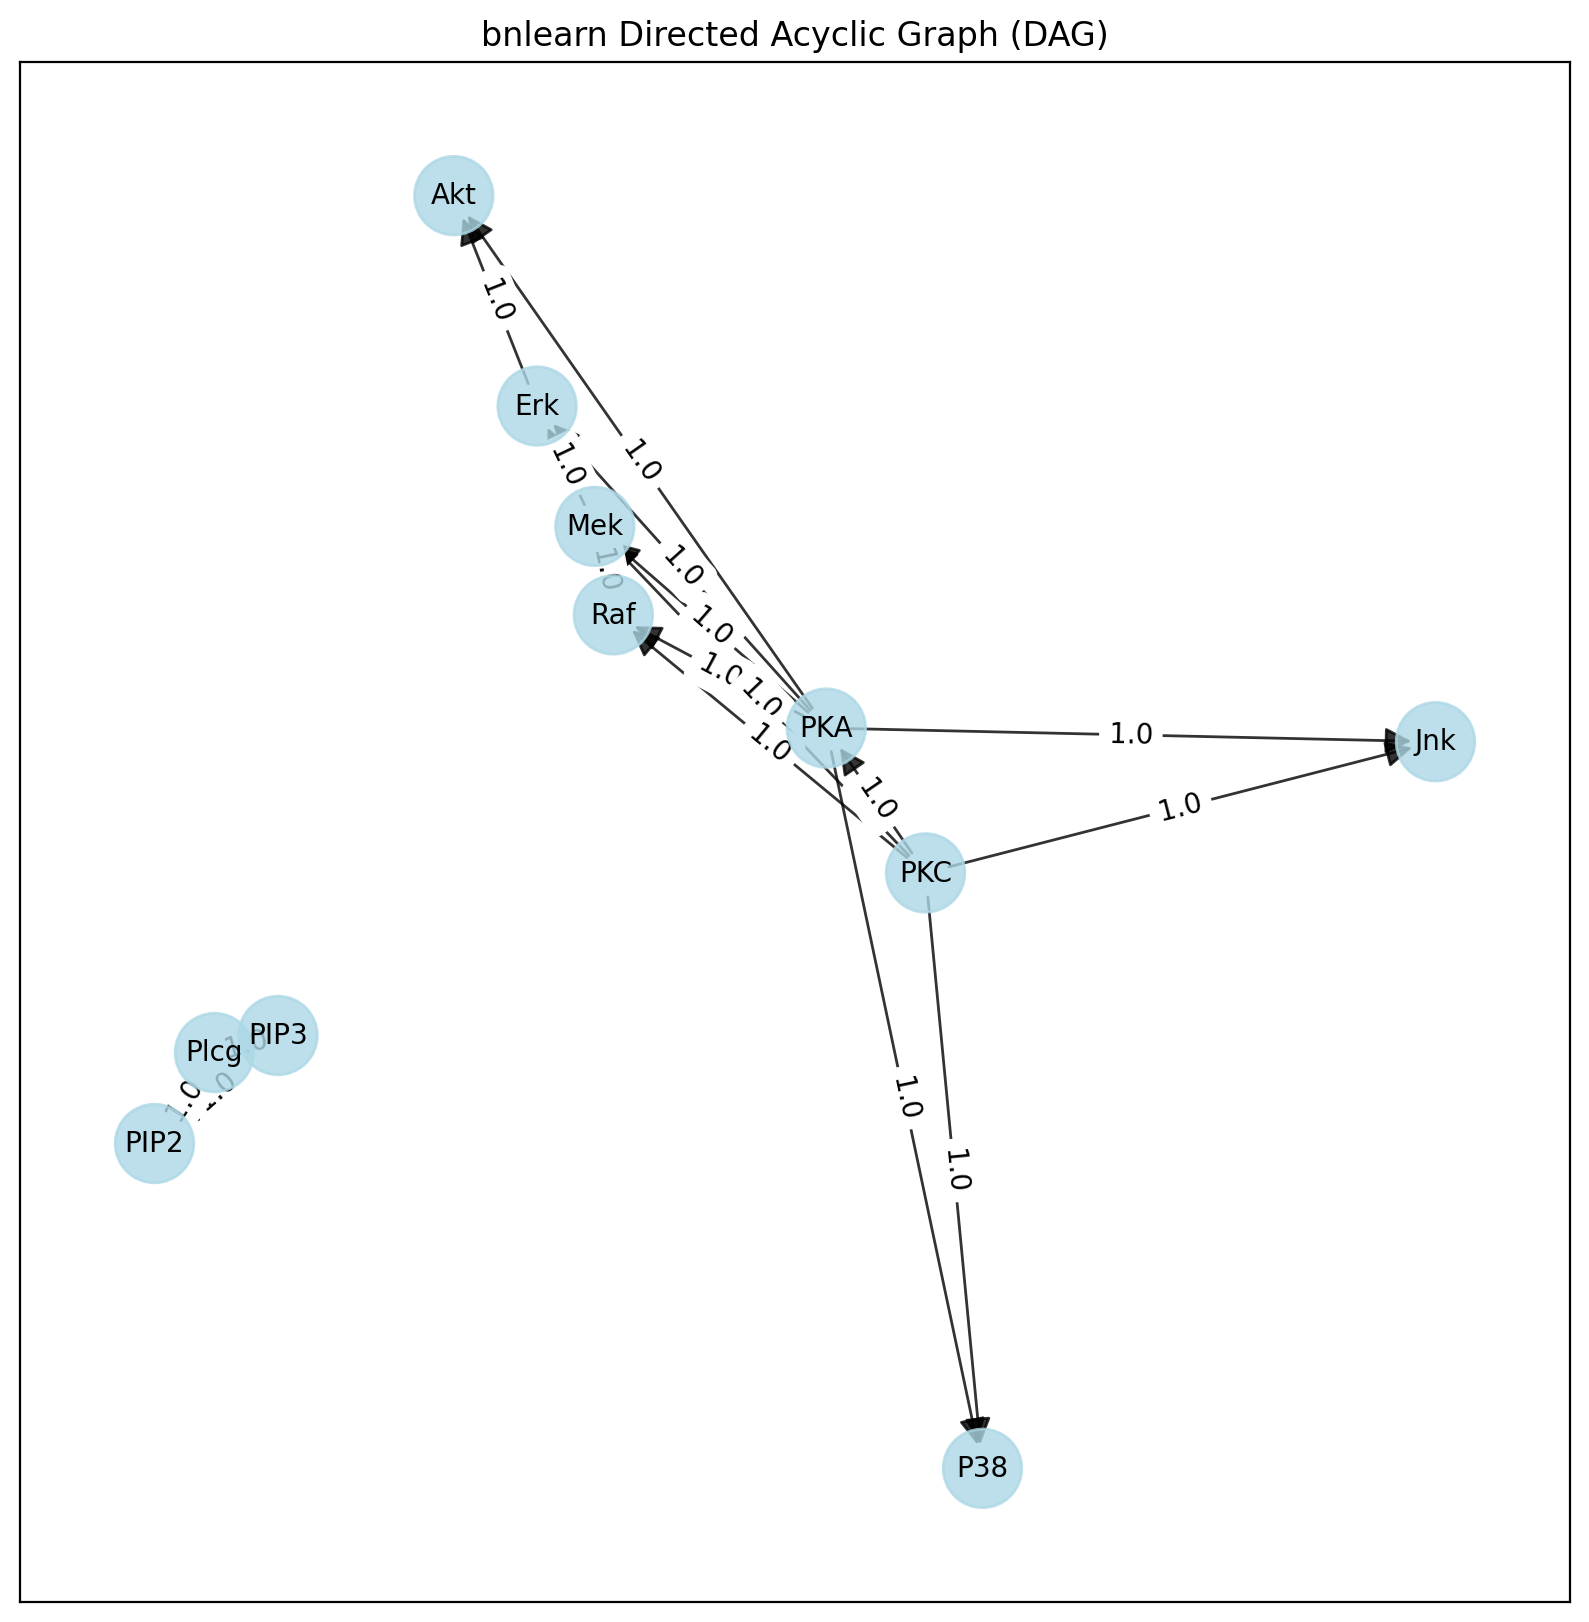

In [46]:
ground_truth_dag = bn.import_DAG("sachs", verbose=False)
fig = bn.plot(ground_truth_dag)

In [53]:
from itertools import combinations

def dag_to_admg_with_hidden_common_cause(dag_parents, hidden_node, observed_nodes):
    from itertools import combinations

    children = {v: [] for v in dag_parents}
    for child, parents in dag_parents.items():
        for p in parents:
            children[p].append(child)

    node_to_idx = {v: i for i, v in enumerate(observed_nodes)}

    admg = {
        node_to_idx[v]: {"parents": [], "spouses": []}
        for v in observed_nodes
    }

    # directed edges among observed nodes
    for child, parents in dag_parents.items():
        if child not in node_to_idx:
            continue

        child_idx = node_to_idx[child]
        for p in parents:
            if p in node_to_idx:
                admg[child_idx]["parents"].append(node_to_idx[p])

    # bidirected clique among children of hidden_node
    hidden_children = [c for c in children[hidden_node] if c in node_to_idx]

    for u, v in combinations(hidden_children, 2):
        i, j = node_to_idx[u], node_to_idx[v]
        admg[i]["spouses"].append(j)
        admg[j]["spouses"].append(i)

    for i in admg:
        admg[i]["parents"] = sorted(set(admg[i]["parents"]))
        admg[i]["spouses"] = sorted(set(admg[i]["spouses"]))

    return admg, node_to_idx

In [55]:
var_names = list(df_obs.columns)

admg, node_to_idx = dag_to_admg_with_hidden_common_cause(
    dag_parents=dag_parents,
    hidden_node="PKC",
    observed_nodes=var_names
)

print(node_to_idx)
print(admg)

{'Erk': 0, 'Akt': 1, 'PKA': 2, 'Mek': 3, 'Jnk': 4, 'Raf': 5, 'P38': 6, 'PIP3': 7, 'PIP2': 8, 'Plcg': 9}
{0: {'parents': [2, 3], 'spouses': []}, 1: {'parents': [0, 2], 'spouses': []}, 2: {'parents': [], 'spouses': [3, 4, 5, 6]}, 3: {'parents': [2, 5], 'spouses': [2, 4, 5, 6]}, 4: {'parents': [2], 'spouses': [2, 3, 5, 6]}, 5: {'parents': [2], 'spouses': [2, 3, 4, 6]}, 6: {'parents': [2], 'spouses': [2, 3, 4, 5]}, 7: {'parents': [9], 'spouses': []}, 8: {'parents': [7, 9], 'spouses': []}, 9: {'parents': [], 'spouses': []}}


In [ ]:
{0: {'parents': [2, 3], 'spouses': []}, 1: {'parents': [0, 2], 'spouses': []}, 2: {'parents': [], 'spouses': [3, 4, 5, 6]}, 3: {'parents': [2, 5], 'spouses': [2, 4, 5, 6]}, 4: {'parents': [2], 'spouses': [2, 3, 5, 6]}, 5: {'parents': [2], 'spouses': [2, 3, 4, 6]}, 6: {'parents': [2], 'spouses': [2, 3, 4, 5]}, 7: {'parents': [9], 'spouses': []}, 8: {'parents': [7, 9], 'spouses': []}, 9: {'parents': [], 'spouses': []}}

In [49]:
labels

['Raf',
 'Mek',
 'Plcg',
 'PIP2',
 'PIP3',
 'Erk',
 'Akt',
 'PKA',
 'PKC',
 'P38',
 'Jnk']

In [50]:
data[0:5]

array([[ 26.4 ,  13.2 ,   8.82,  18.3 ,  58.8 ,   6.61,  17.  , 414.  ,
         17.  ,  44.9 ,  40.  ],
       [ 35.9 ,  16.5 ,  12.3 ,  16.8 ,   8.13,  18.6 ,  32.5 , 352.  ,
          3.37,  16.5 ,  61.5 ],
       [ 59.4 ,  44.1 ,  14.6 ,  10.2 ,  13.  ,  14.9 ,  32.5 , 403.  ,
         11.4 ,  31.9 ,  19.5 ],
       [ 73.  ,  82.8 ,  23.1 ,  13.5 ,   1.29,   5.83,  11.8 , 528.  ,
         13.7 ,  28.6 ,  23.1 ],
       [ 33.7 ,  19.8 ,   5.19,   9.73,  24.8 ,  21.1 ,  46.1 , 305.  ,
          4.66,  25.7 ,  81.3 ]])

In [51]:
X_truth[0:5]

tensor([[  6.6100,  17.0000, 414.0000,  13.2000,  40.0000,  26.4000,  44.9000,
          58.8000,  18.3000,   8.8200],
        [ 18.6000,  32.5000, 352.0000,  16.5000,  61.5000,  35.9000,  16.5000,
           8.1300,  16.8000,  12.3000],
        [ 14.9000,  32.5000, 403.0000,  44.1000,  19.5000,  59.4000,  31.9000,
          13.0000,  10.2000,  14.6000],
        [  5.8300,  11.8000, 528.0000,  82.8000,  23.1000,  73.0000,  28.6000,
           1.2900,  13.5000,  23.1000],
        [ 21.1000,  46.1000, 305.0000,  19.8000,  81.3000,  33.7000,  25.7000,
          24.8000,   9.7300,   5.1900]], dtype=torch.float64)

In [52]:
data

array([[2.640e+01, 1.320e+01, 8.820e+00, ..., 1.700e+01, 4.490e+01,
        4.000e+01],
       [3.590e+01, 1.650e+01, 1.230e+01, ..., 3.370e+00, 1.650e+01,
        6.150e+01],
       [5.940e+01, 4.410e+01, 1.460e+01, ..., 1.140e+01, 3.190e+01,
        1.950e+01],
       ...,
       [2.810e+01, 4.490e+00, 1.880e+01, ..., 1.000e+00, 1.750e+00,
        2.000e+00],
       [3.460e+01, 7.100e+00, 5.730e+00, ..., 4.450e+01, 1.382e+03,
        2.440e+00],
       [3.050e+01, 1.010e+00, 7.300e+00, ..., 1.000e+00, 1.000e+00,
        1.650e+00]], shape=(7466, 11))